In [5]:
import sys
import os
import time
import json
from pathlib import Path

from collections.abc import Callable

import numpy as np
import pandas as pd

import datasets

import translators as ts # API to get translations from Google / Bing

from nltk.translate import bleu_score
from bleurt import score

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from transformers import T5ForConditionalGeneration, T5Tokenizer

We get the SMOLSent English->Cantonese data using our train/validation/test split and Gatitos Cantonese->Mandarin Chinese data from Huggingface

In [39]:
rel_path = Path(".")
en_yue_sentences_validation = pd.read_json(path_or_buf=rel_path / "smoldata/smol_en_yue_sentences/validation.json", lines=True)
yue_zh_characters_validation = datasets.load_dataset("google/smol", "gatitos__yue_zh")

We then benchmark on Google's and Bing's proprietary translation models as a state-of-the-art reference to explore if Cantonese models outperform Chinese models on Cantonese translation tasks. 

In [ ]:
services = ["bing", "google"]
langs = {
    "bing": ["chinese (simplified)", "chinese (traditional)", "cantonese"],
    "google": ["chinese"]
}

lang_map = {
    "bing": {"chinese (simplified)" : "zh-Hans", "chinese (traditional)": "zh-Hant", "cantonese": "yue", "english": "en"},
    "google": {"chinese": "zh", "english": "en"}
}

all_trans: list[dict] = []


if os.path.isfile(rel_path / "evaluation_translations" / "translation_service_en_yue_sentence_validation.json"):
    with open(rel_path / "evaluation_translations" / "translation_service_en_yue_sentence_validation.json", "r") as f:
        all_trans = json.load(f)
else:
    for index, sentence in tqdm(en_yue_sentences_validation.iterrows(), total=en_yue_sentences_validation.shape[0]):
    
        translations = {
            "original_eng": sentence["src"],
            "original_yue": sentence["trg"]
        }

        for service in services:

            attempts = 0
            while attempts < 3:
                try:
                    trans = {language: {"translation":ts.translate_text(sentence["trg"], translator="bing", from_language=lang_map[service][language], to_language=lang_map[service]["english"])} for language in langs[service] }
                    translations[service] = trans
                    break
                except KeyboardInterrupt:
                    sys.exit(1)
                except:
                    tqdm.write(f"error on sentece {sentence['id']}, retrying... ({attempts + 1})")
                    attempts += 1
                    time.sleep(3)
            if attempts == 3:
                tqdm.write(f"skipped sentence {sentence['id']} after {attempts+1} attempts")
                continue
        
        all_trans.append(translations)

In [7]:
def bleu(ref, cand):
    return bleu_score.sentence_bleu(
            [ref.split()], 
            cand.split(), 
                #use smoothing method 7 that had best chinese->english human-evaluation corerlation from https://aclanthology.org/W14-3346/
            smoothing_function= bleu_score.SmoothingFunction().method7 
            )

def benchmark(all_trans: list[dict], metric: Callable[[str, str], float], metric_name: str, services: list[str], langs: dict[str, list[str]]):
    with tqdm(total = len(all_trans) * np.sum([len(langs[service]) for service in services]), leave=True) as pbar:
        for i, trans in enumerate(all_trans):
            for service in services:
                for lang in langs[service]:
                    all_trans[i][service][lang][metric_name] = metric(trans["original_eng"], trans[service][lang]["translation"])
                    pbar.update()

def print_benchmark(all_trans, metric_name, services, langs):
    for service in services:
            for lang in langs[service]:
                print(f'{service:10s} - {lang:25s}: {np.mean([trans[service][lang][metric_name] for trans in all_trans]):.4f} {metric_name}')

In [43]:
benchmark(all_trans, bleu, "bleu", services, langs)
print_benchmark(all_trans, "bleu", services, langs)

100%|██████████| 692/692 [00:00<00:00, 3252.93it/s]

bing       - chinese (simplified)     : 0.2920 bleu
bing       - chinese (traditional)    : 0.3061 bleu
bing       - cantonese                : 0.2885 bleu
google     - chinese                  : 0.2929 bleu


Since BLEU is a n-gram based evaluation proxy it evaluates sentences badly when they don't share vocabulary or word order with the reference, even if the semantic meaning is conserved. This can be seen below where Bing's chinese traditional model scores vastly above the others even though it has the same semantic meaning.  

In [3]:
def print_sentences(sent_trans: dict[str, dict[str, dict[str, str]]], langs: dict[str, list[str]]):
    print(f'{"original":29s} : {sent_trans["original_eng"]}')
    [print(f'bing   {lang:22s} : {sent_trans["bing"][lang]["translation"]}') for lang in langs["bing"]]
    [print(f'google {lang:22s} : {sent_trans["google"][lang]["translation"]}') for lang in langs["google"]]
    print(f'{"original yue":29s} : {sent_trans["original_yue"]}')

In [45]:
i = 8
print_sentences(all_trans[i])
print("\n")
print_benchmark([all_trans[i]], "bleu", services, langs)

original                      : Since James’ injury, they have the fourth-best defensive rating in the league.
bing   chinese (simplified)   : Since James got injured, they have had the fourth best defensive rating in the league.
bing   chinese (traditional)  : Since James got injured, they have the fourth-best defensive rating in the league.
bing   cantonese              : Since James got injured, they have had the fourth-best defense in the league.
google chinese                : Since James got injured, they have had the fourth best defensive rating in the league.
original yue                  : 自從占姆士受傷之後，佢哋喺聯賽入面有第四好嘅防守率。


bing       - chinese (simplified)     : 0.3849 bleu
bing       - chinese (traditional)    : 0.7682 bleu
bing       - cantonese                : 0.2596 bleu
google     - chinese                  : 0.3849 bleu


For that reason we instead try the model-based evaluation metric BLEURT.

In [46]:
if os.path.isfile(rel_path / "benchmarks" / "all_trans_bleurt-20.json"):
    with open(rel_path / "benchmarks" / "all_trans_bleurt-20.json", "r") as f:
        all_trans = json.load(f)
else:
    def bleurt(ref, cand):
        return scorer.score(references=[ref], candidates=[cand])[0]

    ## ../bleurt/BLEURT-20
    scorer = score.BleurtScorer(Path("BLEURT-20"))
    benchmark(all_trans, bleurt, "bleurt", services, langs)
    json.dump(all_trans, open("all_trans_bleurt-20.json", "w"), indent=4, ensure_ascii=False)

print_benchmark(all_trans, "bleurt", services, langs)

bing       - chinese (simplified)     : 0.7471 bleurt
bing       - chinese (traditional)    : 0.7527 bleurt
bing       - cantonese                : 0.7487 bleurt
google     - chinese                  : 0.7478 bleurt


In [47]:
i = 8
print_sentences(all_trans[i])
print("\n")
print_benchmark([all_trans[i]], "bleurt", services, langs)

original                      : Since James’ injury, they have the fourth-best defensive rating in the league.
bing   chinese (simplified)   : Since James got injured, they have had the fourth best defensive rating in the league.
bing   chinese (traditional)  : Since James got injured, they have the fourth-best defensive rating in the league.
bing   cantonese              : Since James got injured, they have had the fourth-best defense in the league.
google chinese                : Since James got injured, they have had the fourth best defensive rating in the league.
original yue                  : 自從占姆士受傷之後，佢哋喺聯賽入面有第四好嘅防守率。


bing       - chinese (simplified)     : 0.8333 bleurt
bing       - chinese (traditional)    : 0.8670 bleurt
bing       - cantonese                : 0.7847 bleurt
google     - chinese                  : 0.8333 bleurt


Now we can see that we have a better evaluation measure, the two translations that had the same semantic meaning but scored much worse now have around the same score, and the translation that did not translate "rating" scored slightly worse than the others. 

Next we will use the bleurt evaluation metric to filter for bad translations that we can look for patterns in. 

In [48]:
filter_value = 0.6
bad_translations = [trans for trans in all_trans if np.all([np.all([trans[service][lang]["bleurt"] < filter_value for lang in langs[service]]) for service in services])]
print_sentences(bad_translations[0])
print(len(bad_translations))

original                      : Keep your sink shining and free of dirty dishes at all times.
bing   chinese (simplified)   : Always keep your zinc plate tidy, and don't let dirty dishes pile up.
bing   chinese (traditional)  : Keep your zinc tray upright at all times and don't let dirty dishes pile up.
bing   cantonese              : Always keep your zinc plate upright, and don't let dirty dishes pile up.
google chinese                : Always keep your zinc plate tidy, and don't let dirty dishes pile up.
original yue                  : 時刻保持你個鋅盤立立令，唔好俾污糟碗碟堆積。
5


Many bad translations mistranslate words, so we believe it is likely the case that bad translations have more cantonese-specific characters in them, so we plot this relation to see if there is any correlation. 

In [49]:
with open("character_classification.json", "r") as f:
    character_classfication = json.load(f)

In [ ]:
def canto_characters_in_sentence(sentence: str) -> tuple[int, int]:
    canto_only = 0
    for x in sentence:
        if x in character_classfication.keys():
            if character_classfication[x] == "CANTO_ONLY":
                canto_only += 1
    return canto_only, len(sentence)

all_translations_canto_score = {}
for service in services:
    all_translations_canto_score[service] = {}
    for lang in langs[service]:
        all_translations_canto_score[service][lang] = []
        for i in range(len(all_trans)):
            score = all_trans[i][service][lang]["bleurt"]
            canto,length = canto_characters_in_sentence(all_trans[i]["original_yue"])
            all_translations_canto_score[service][lang].append((canto/length, score))

Text(0.5, 0.98, 'bleurt vs cantonese character presence')

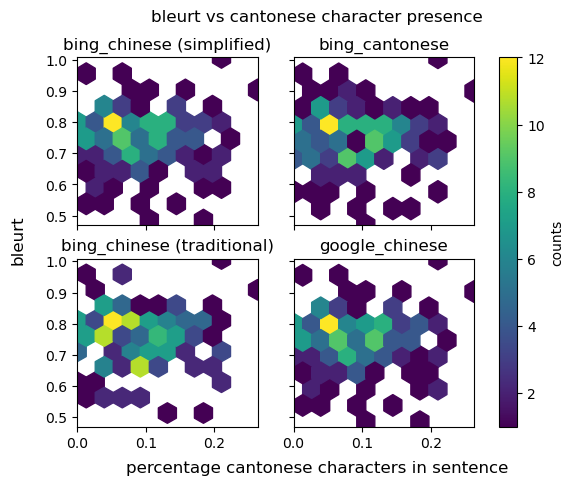

In [51]:
fig, axs = plt.subplots(2,2,sharey=True,sharex=True)

fig_map = {"bing": {"chinese (simplified)": (0,0), "chinese (traditional)": (1,0), "cantonese": (0,1)}, "google": {"chinese": (1,1)}}

hexbin_size = 10
for service in services:
    for lang in langs[service]:
        z = axs[fig_map[service][lang]].hexbin(
    np.array(all_translations_canto_score[service][lang])[:,0].flatten(), 
    np.array(all_translations_canto_score[service][lang])[:,1].flatten(), 
    gridsize=hexbin_size,
    #cmap="ciridis", 
    mincnt=1
    )

        axs[fig_map[service][lang]].set_title(service + "_" + lang)
        axs[fig_map[service][lang]].margins(0)

cb = fig.colorbar(z, ax=axs, label='counts')

fig.supxlabel("percentage cantonese characters in sentence")
fig.supylabel("bleurt")
fig.suptitle("bleurt vs cantonese character presence")

C:\Users\victo\AppData\Local\Temp\ipykernel_8760\3435023842.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)


Text(0.5, 1.0, 'bing & google model translations')

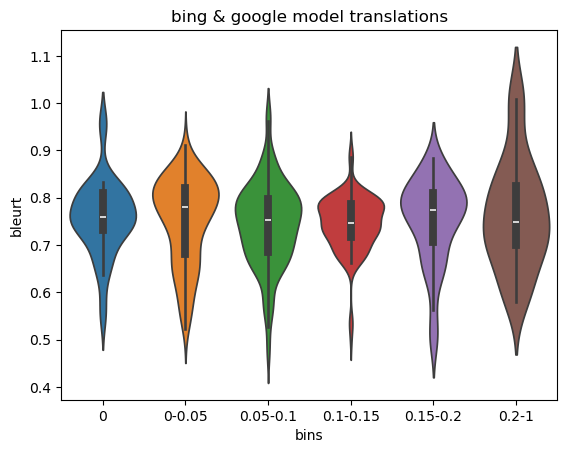

In [52]:
bins = [0]

v = np.array(all_translations_canto_score["bing"]["chinese (simplified)"] + all_translations_canto_score["bing"]["chinese (traditional)"] + all_translations_canto_score["bing"]["cantonese"] + all_translations_canto_score["google"]["chinese"])

bin_ranges = [0, 0.0001, 0.05, 0.1, 0.15, 0.2, 1]


bins = [np.argwhere((v[:,0] >= bin_ranges[i]) & (v[:,0] < bin_ranges[i+1]) ) for i in range(len(bin_ranges) - 1)]

ax = sns.violinplot([v[bin, 1].flatten() for bin in bins])
xtick_labels = [str(bin_ranges[i]) + "-" + str(bin_ranges[i+1]) for i in range(len(bin_ranges)-1)]
xtick_labels[0] = "0"
xtick_labels[1] = "0-0.05"
ax.set_xticklabels(xtick_labels)

ax.set_ylabel("bleurt")
ax.set_xlabel("bins")
ax.set_title("bing & google model translations")

It appears that there is no clear correlation between percentage cantonese characters and model performance for state of the art models. 

We do another test with a local multilingual large language model (MADLAD400 3B-mt)

In [ ]:
with open(rel_path / "evaluation_translations" / "sentence_translations_madlad400-3b.json", "r") as f:
    madlad_translations: list[dict] = json.load(f)

In [54]:
if os.path.isfile(rel_path / "benchmarks" / "sentence_translations_madlad400-3b_bleurt.json"):
    with open(rel_path / "benchmarks" / "sentence_translations_madlad400-3b_bleurt.json", "r") as f:
        madlad_translations = json.load(f)
else:
    for x in tqdm(madlad_translations):
        x["bleurt"] = bleurt(x["original"], x["cantonese"])
        canto, length = canto_characters_in_sentence(x["original_yue"])
        x["canto_percent"] = canto/length
    json.dump(madlad_translations, open("sentence_translations_madlad400-3b_bleurt.json", "w"), indent=4, ensure_ascii=False)

In [55]:
[np.mean([x["bleurt"] for x in madlad_translations])]

[np.float64(0.6992631363386363)]

The MADLAD model is quite a bit worse than state of the art, but it is a good model to experiment with for us as it is smaller and has been exposed to Cantonese data. 

Text(0, 0.5, 'bleurt')

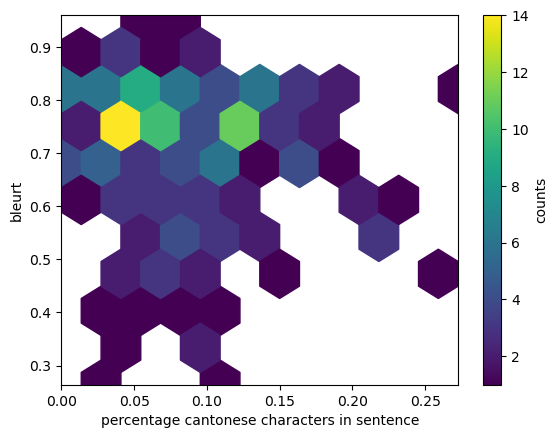

In [56]:
madlad_relation = np.array([(x["canto_percent"], x["bleurt"]) for x in madlad_translations])
z = plt.hexbin(madlad_relation[:,0], madlad_relation[:,1], gridsize=hexbin_size, mincnt=1)

plt.colorbar(z, label="counts")
plt.margins(0)

plt.xlabel("percentage cantonese characters in sentence")
plt.ylabel("bleurt")

C:\Users\victo\AppData\Local\Temp\ipykernel_8760\1121944237.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)


Text(0.5, 1.0, 'madlad400 3B-mt translations')

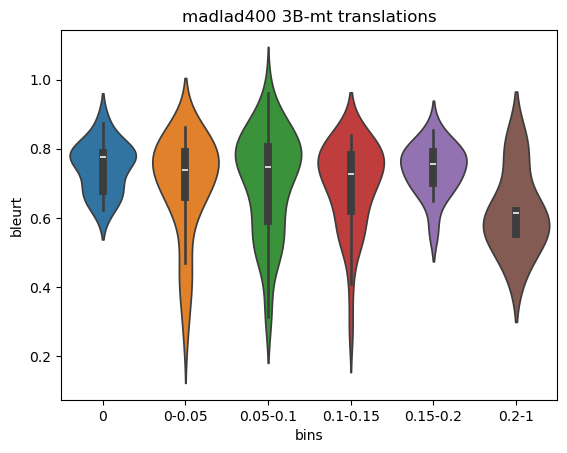

In [57]:
v = np.array(madlad_relation)

bin_ranges = [0, 0.001, 0.05, 0.1, 0.15, 0.2, 1]

bins = [np.argwhere((v[:,0] >= bin_ranges[i]) & (v[:,0] < bin_ranges[i+1]) ) for i in range(len(bin_ranges) - 1)]

ax = sns.violinplot([v[bin, 1].flatten() for bin in bins])
xtick_labels = [str(bin_ranges[i]) + "-" + str(bin_ranges[i+1]) for i in range(len(bin_ranges)-1)]
xtick_labels[0] = "0"
xtick_labels[1] = "0-0.05"
ax.set_xticklabels(xtick_labels)

ax.set_ylabel("bleurt")
ax.set_xlabel("bins")
ax.set_title("madlad400 3B-mt translations")

Unlike in the state of the art models we can see a clear pattern here, the model does very well on sentences that only contain mandarin characters, and performance significantly degrades as more of the sentence is made up of cantonese characters. 

In [ ]:
def canto_characters_in_sentence(sentence: str) -> list[str]:
    canto_chars = []
    for x in sentence:
        if x in character_classfication.keys():
            if character_classfication[x] == "CANTO_ONLY":
                canto_chars.append(x)
    return canto_chars

len([x for x in madlad_translations if len(canto_characters_in_sentence(x["original_yue"])) > 0]) / len(madlad_translations)

0.9248554913294798

Since 92% of the sentences include cantonese-only characters, trying to improve these sentences could be a big source of improvement. Next we will examine if using the Gatitos character-level translations to replace Cantonese-only characters will improve MADLAD performance. If this is the case, then MADLAD likely has problems in its embeddings and more advanced embedding-based approaches could lead to significant improvements. 

In [75]:
bad_translations = []
for trans in madlad_translations:
    if trans["bleurt"] < 0.5:
        if np.all([x in yue_zh_characters_validation["train"]["src"] for x in canto_characters_in_sentence(trans["original_yue"])]):
            bad_translations.append(trans)

len(bad_translations)

10

We first try to do direct character replacements from Cantonese to Mandarin characters using the gatitos token level translations. 

Since gatitos also had more than one character we also explore how the translations perform if we to a replacing of more characters.
An example where this was relevant is '椰菜' which refers to cabbage, but literally means ["coconut vegetable"](https://en.wiktionary.org/wiki/%E6%A4%B0%E8%8F%9C). So only doing 1 character replacements would result in this being translated to coconut, but doing multiple character replacements would result in this being translated correctly to cabbage.

In [ ]:
with open("character_classification.json", "r") as f:
    character_classfication: dict[str, str] = json.load(f)
    
# The 19 worst MADLAD400-3b SmolSent en_yue translations (ranked by BLEURT)
with open("evaluation_translations/bad_translations.json", "r", encoding="utf-8") as f:
    bad_translations: list[dict] = json.load(f)

This is the function use to replace single characters

In [67]:
def replace_canto_only_characters(s: str) -> None | str:
    s_out = []
    for c in s:
        is_canto_only = c in character_classfication and character_classfication[c] == 'CANTO_ONLY'
        is_in_gatitos = c in yue_zh_characters_validation['train']['src'] # type: ignore
        if is_canto_only and is_in_gatitos: # type: ignore
            token_translations = [x for x in yue_zh_characters_validation['train'] if x['src'] == c] # type: ignore
            s_out.append(token_translations[0]['trgs'][-1]) # type: ignore
        else:
            s_out.append(c)
            
    return ''.join(s_out)

This is the function used to generate complete gatitos token replacements.

In [78]:
characters = yue_zh_characters_validation["train"].to_pandas().sort_values(by="src", key=lambda x:x.str.len(), ascending=False)

def swap_tokens(sentence: str) -> str:
    result = ""
    i = 0
    while i < len(sentence):
        found = False
        for k in range(len(characters)):
            if characters["src"][k] == sentence[i:i+len(characters["src"][k] )]:
                result = result + characters["trgs"][k][0].split(";")[0]
                i += len(characters["src"][k])
                found = True
                break
        if not found:
            result += sentence[i]
            i += 1
    
    return result


In [ ]:
if os.path.exists('evaluation_translations/sentence_translations_madlad_token_replacements.json'):
    with open('evaluation_translations/sentence_translations_madlad_token_replacements.json', 'r') as f:
        results: list[dict] = json.load(f)
else:
    model_name = 'jbochi/madlad400-3b-mt'
    model = T5ForConditionalGeneration.from_pretrained(model_name, device_map=None)
    tokenizer = T5Tokenizer.from_pretrained(model_name)

    results = []

    def translate(cantonese: str) -> str:
        text = f"<2en> {cantonese}"
        input_ids = tokenizer(text, return_tensors="pt").input_ids.to(model.device)
        outputs = model.generate(input_ids=input_ids, max_new_tokens=256)
        return tokenizer.decode(outputs[0], skip_special_tokens=True)

    for item in bad_translations:
        translation_plain = translate(item['original_yue'])
        translation_swapped_tokens = translate(swap_tokens(item['original_yue']))
        translation_replaced_chars = translate(replace_canto_only_characters(item['original_yue'])) # type: ignore

        record = {
            "original": item['original'], # This is the original english sentence
            "cantonese": translation_plain, # This is the english sentence translated from Cantonese
            "tkn-swaps": translation_swapped_tokens, # This is the english sentence translated from Cantonese with multiple character token replacements
            "chr-swaps": translation_replaced_chars, # This is the english sentence translated from Cantonese with single character token replacements
        }

        results.append(record)

    with open('evaluation_translations/sentence_translations_madlad_token_replacements.json', 'w+') as f:
        json.dump(results, f, indent=4)


We manually inspected the resulting translations and found some of the translations had improved significantly for example the following:
```json
    {
        "original": "Rohan was my sibling who always flew a kite at noon, even if it was cloudy.",
        "cantonese": "The bridge is opened to the public at noon, and closed at midnight.",
        "tkn-swaps": "Rohan is my brother, and he flies kites at noon every day, even when the sky is dark.",
        "chr-swaps": "Rohan is my brother, and he flies kites every day at noon, even in the dark."
    }
```
Here we can see that the version translated directly from Cantonese bears little to no resemblance to the original English version. But the versions using gatitos replacements do.

This example shows how doing multiple character gatitos replacements can improve results over using single character replacements:
```json
    {
        "original": "Not to mention democrats are already split over the infrastructure bill, lmao.",
        "cantonese": "The government has not yet made any official statement on the issue, but the opposition has been calling for a referendum on the issue, which is being held in the country.",
        "tkn-swaps": "I don't think the Democrats themselves have a different opinion on that infrastructure bill, haha.",
        "chr-swaps": "The government has not yet made any official statement on the issue, but the opposition has been calling for a referendum on the issue, which has been delayed."
    }
```

Some of the sentences did not improve, mostly because they were already decent translations (according to our manual inspection).

For character level swaps, of the 19 bad-translation sentences we tested on, the method improved the translation quality of 7 sentences. Of the remaining 12 sentences, 6 were already good and 6 did not get better. 

For word level swaps, of the 19 bad-translation sentences we tested on, the method improved the translation quality of 11 sentences. Of the remaining 8 sentences, 6 were already good, and 2 did not get better.

[Text(0, 0, 'became good'),
 Text(1, 0, 'was already alright'),
 Text(2, 0, 'did not become better')]

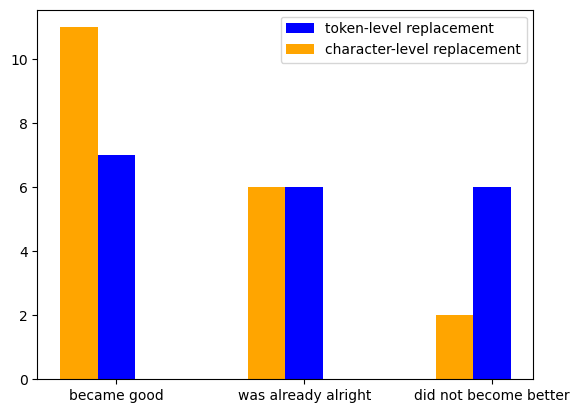

In [93]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax1 = ax.bar(np.arange(3), [7,6,6],width=0.2 ,align="center", color="blue")
ax2 = ax.bar(np.arange(3)-0.2, [11,6,2],width=0.2, align="center", color="orange")
ax.legend( (ax1[0], ax2[0]), ('token-level replacement', 'character-level replacement') )
ax.set_xticks(np.arange(3))
ax.set_xticklabels(("became good", "was already alright", "did not become better"))